# **EDA: XGBoost for PJME Electricity Consumption Data**

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# global plot style
plt.style.use('fivethirtyeight')
sns.set_theme(
  style='darkgrid',
  palette='muted',
  rc={
    'figure.figsize': (15, 5),
    'axes.titlesize': 20,
    'axes.titleweight': 'bold',
  }
)

---

### Load & Preview Dataset

In [16]:
df = pd.read_csv("../data/processed/PJME_hourly_processed.csv")
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df = df.sort_index()
print(f"No. rows: {df.shape[0]}")
df.head()

No. rows: 119139


,PJME_MW,hour,dayofweek,month,quarter,year,dayofyear,dayofmonth,weekofyear,lag1,...,rolling_mean_24h,rolling_mean_168h,is_holiday,temperature,heating_degrees,cooling_degrees,rolling_temp_24h,rolling_temp_168h,is_weekend,is_peak_hour
Datetime,,,,,,,,,,,,,,,,,,,,,
2004-12-28 01:00:00,33781.0,1,1,12,4,2004,363,28,53,26506.0,...,36852.708333,34119.214286,0,-7.200,25.500,0.0,-4.263542,-0.352827,0,0
2004-12-28 02:00:00,32732.0,2,1,12,4,2004,363,28,53,25295.0,...,36991.416667,34107.529762,0,-7.500,25.800,0.0,-4.479167,-0.342857,0,0
2004-12-28 03:00:00,32427.0,3,1,12,4,2004,363,28,53,24562.0,...,37124.166667,34097.279762,0,-7.300,25.600,0.0,-4.705208,-0.335863,0,0
2004-12-28 04:00:00,32474.0,4,1,12,4,2004,363,28,53,24344.0,...,37256.625000,34087.928571,0,-7.500,25.800,0.0,-4.912500,-0.328423,0,0
2004-12-28 05:00:00,33073.0,5,1,12,4,2004,363,28,53,24659.0,...,37382.250000,34080.559524,0,-7.725,26.025,0.0,-5.114583,-0.324107,0,0


---

## EDA

In [17]:
TARGET = 'PJME_MW'

In [18]:
df.describe(include='all')

,PJME_MW,hour,dayofweek,month,quarter,year,dayofyear,dayofmonth,weekofyear,lag1,...,rolling_mean_24h,rolling_mean_168h,is_holiday,temperature,heating_degrees,cooling_degrees,rolling_temp_24h,rolling_temp_168h,is_weekend,is_peak_hour
count,119139.000000,119139.000000,119139.000000,119139.000000,119139.000000,119139.000000,119139.000000,119139.000000,119139.000000,119139.000000,...,119139.000000,119139.000000,119139.000000,119139.000000,119139.000000,119139.00000,119139.000000,119139.000000,119139.000000,119139.000000
mean,32134.734663,11.503462,2.998355,6.421080,2.476410,2011.297006,179.998565,15.732246,26.144688,32212.903054,...,32133.629914,32131.649900,0.027195,12.786275,7.461285,1.94756,12.782739,12.767476,0.285305,0.541871
std,6508.853646,6.921209,1.999244,3.438562,1.114025,3.930415,105.139959,8.805799,15.020340,6503.925845,...,4749.031667,4065.770873,0.162652,10.184252,7.935201,3.41888,9.708230,9.290267,0.451562,0.498246
min,14544.000000,0.000000,0.000000,1.000000,1.000000,2004.000000,1.000000,1.000000,1.000000,14544.000000,...,19307.416667,24334.416667,0.000000,-19.875000,0.000000,0.00000,-15.417708,-10.274554,0.000000,0.000000
25%,27631.000000,6.000000,1.000000,3.000000,1.000000,2008.000000,89.000000,8.000000,13.000000,27692.000000,...,28576.937500,28750.934524,0.000000,4.550000,0.000000,0.00000,4.598958,4.747693,0.000000,0.000000
50%,31417.000000,12.000000,3.000000,6.000000,2.000000,2011.000000,178.000000,16.000000,26.000000,31533.000000,...,31387.375000,31575.196429,0.000000,13.275000,5.025000,0.00000,13.265625,12.977530,0.000000,1.000000
75%,35707.500000,18.000000,5.000000,9.000000,3.000000,2015.000000,270.500000,23.000000,39.000000,35808.000000,...,35056.416667,34911.309524,0.000000,21.275000,13.750000,2.97500,21.681250,21.764211,1.000000,1.000000
max,62009.000000,23.000000,6.000000,12.000000,4.000000,2018.000000,366.000000,31.000000,53.000000,62009.000000,...,52261.416667,47230.702381,1.000000,38.825000,38.175000,20.52500,33.197917,29.844643,1.000000,1.000000


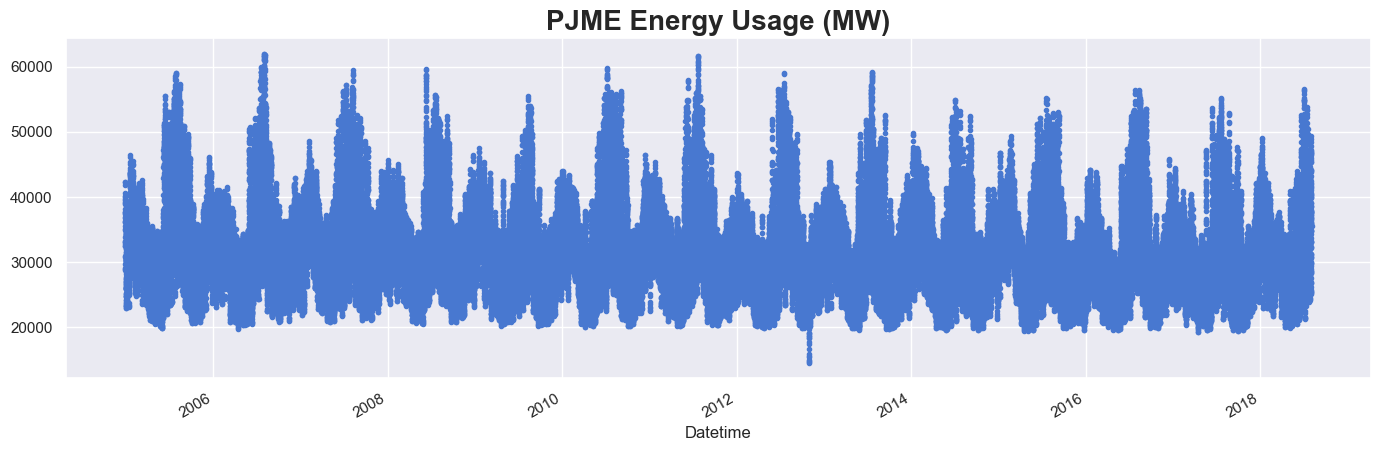

In [19]:
df[TARGET].plot(
  style='.', 
  title="PJME Energy Usage (MW)"
)
plt.show()

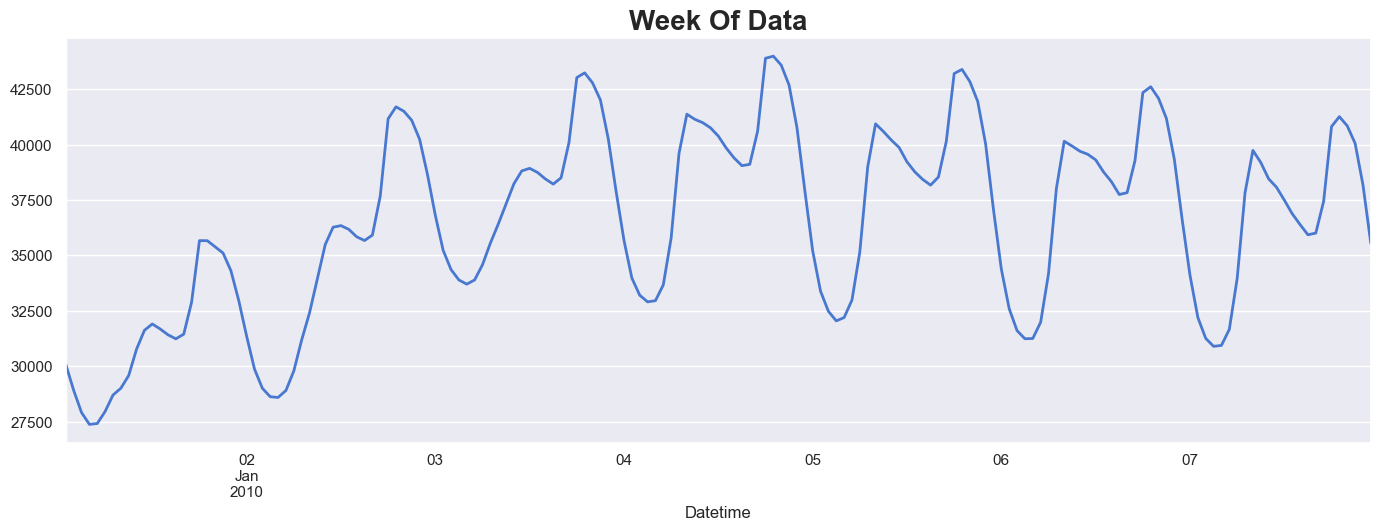

In [26]:
df.loc[(df.index > '2010-01-01') & (df.index < '2010-01-08'), TARGET] \
  .plot(figsize=(15, 5), title='Week Of Data', linewidth=2)
plt.show()

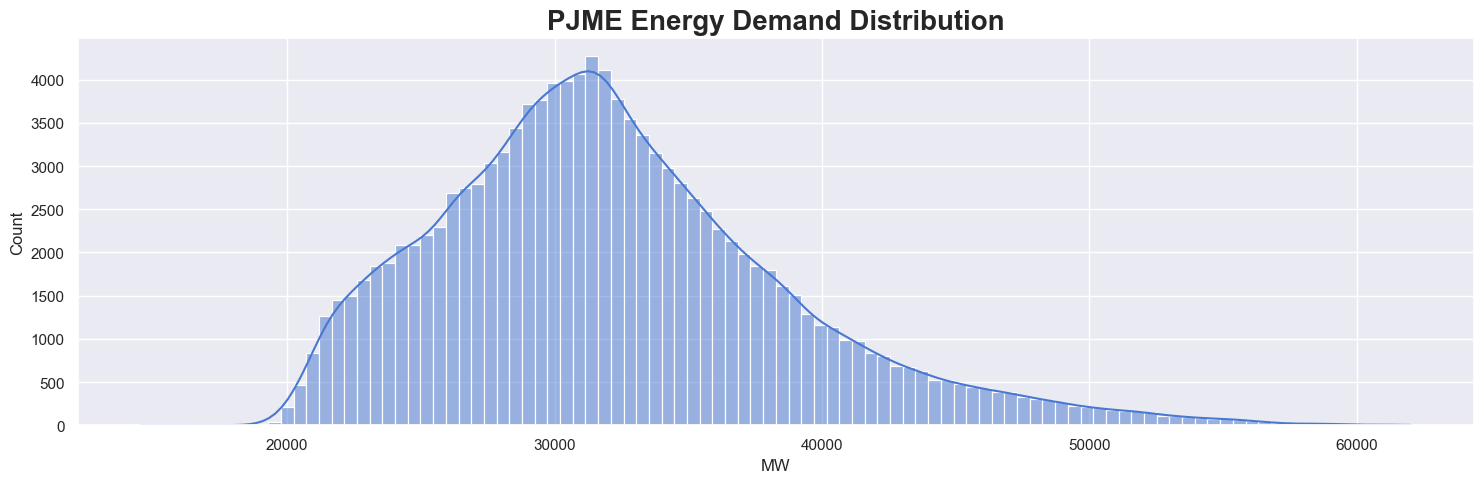

In [21]:
sns.histplot(
  data=df,
  x='PJME_MW',
  bins=100,
  kde=True
)
plt.title('PJME Energy Demand Distribution')
plt.xlabel('MW')
plt.tight_layout()
plt.show()

### Investigate Anomalous Trough around 2013

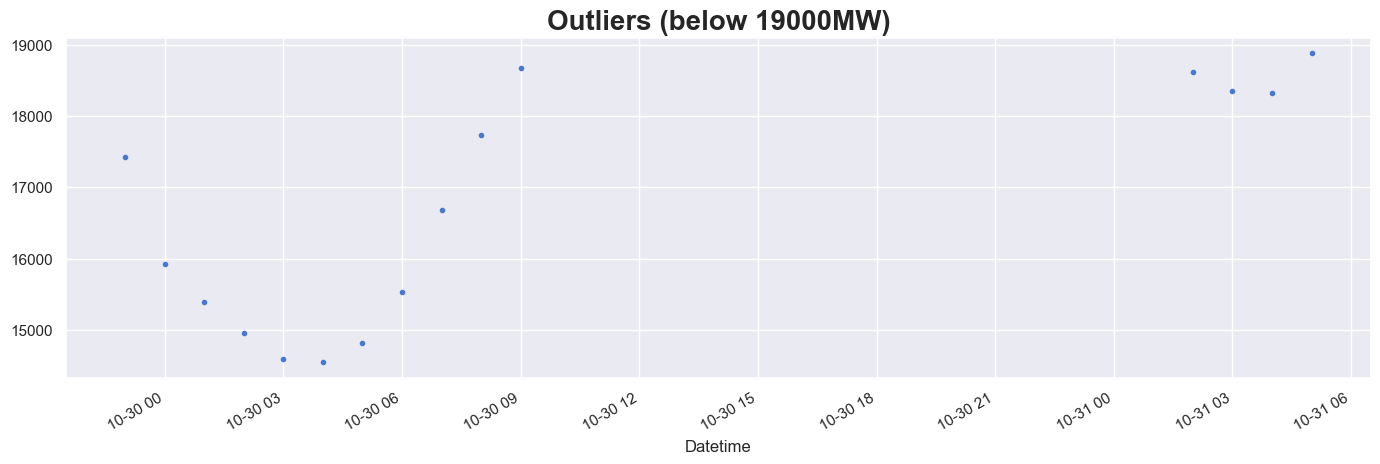

In [22]:
df.loc[(df["PJME_MW"] < 19000), "PJME_MW"].plot(
  style=".",
  title="Outliers (below 19000MW)"
)
plt.show()

In [23]:
# Remove outlier data
df = df.query("PJME_MW > 19000")
df.describe().loc[["min", "max"], "PJME_MW"]

min    19085.0
max    62009.0
Name: PJME_MW, dtype: float64

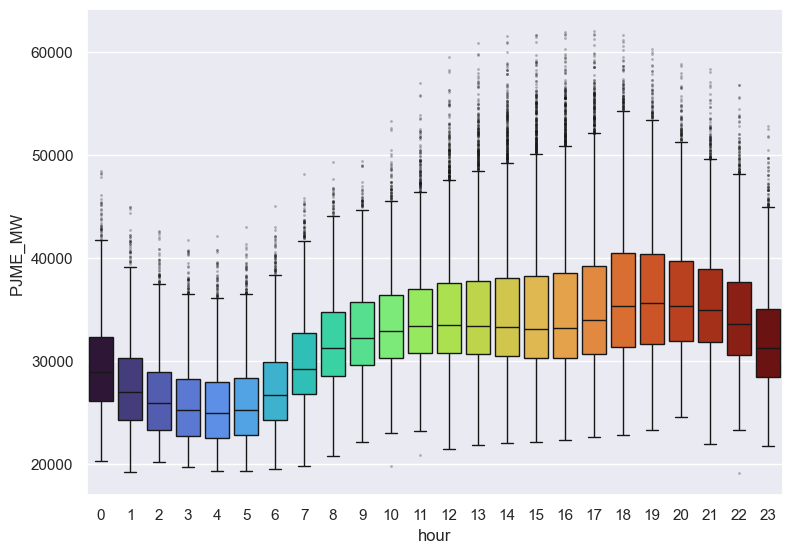

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(
  data=df, 
  x='hour', y='PJME_MW',
  palette='turbo', hue="hour", legend=False,
  flierprops=dict(marker='o', markersize=1, alpha=0.3)
)
plt.show()

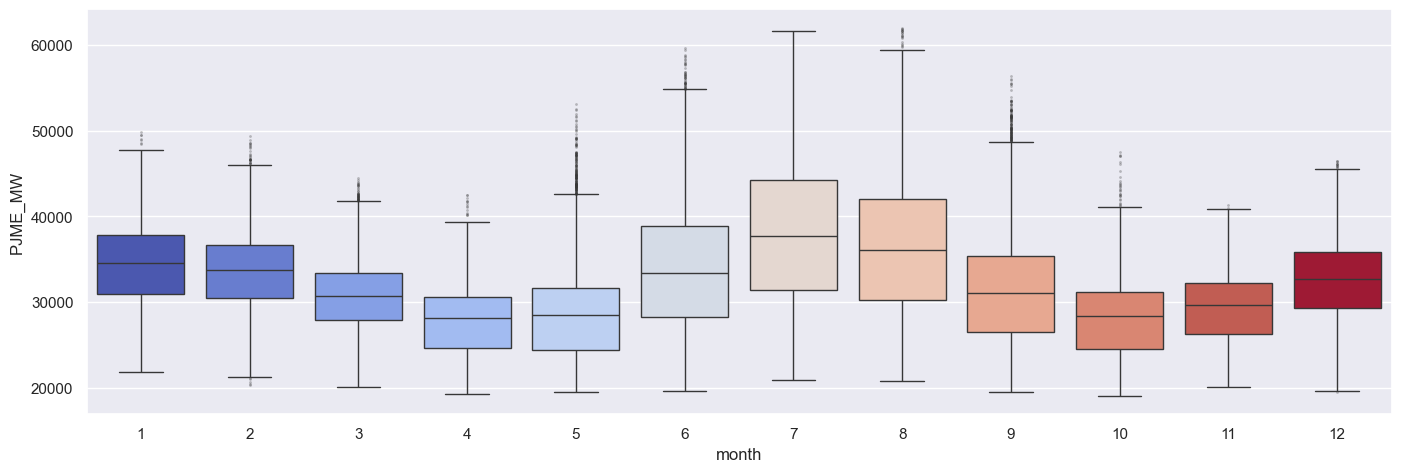

In [25]:
sns.boxplot(
  data=df, 
  x='month', y='PJME_MW',
  palette='coolwarm', hue="month", legend=False,
  flierprops=dict(marker='o', markersize=1, alpha=0.3)
)
plt.show()

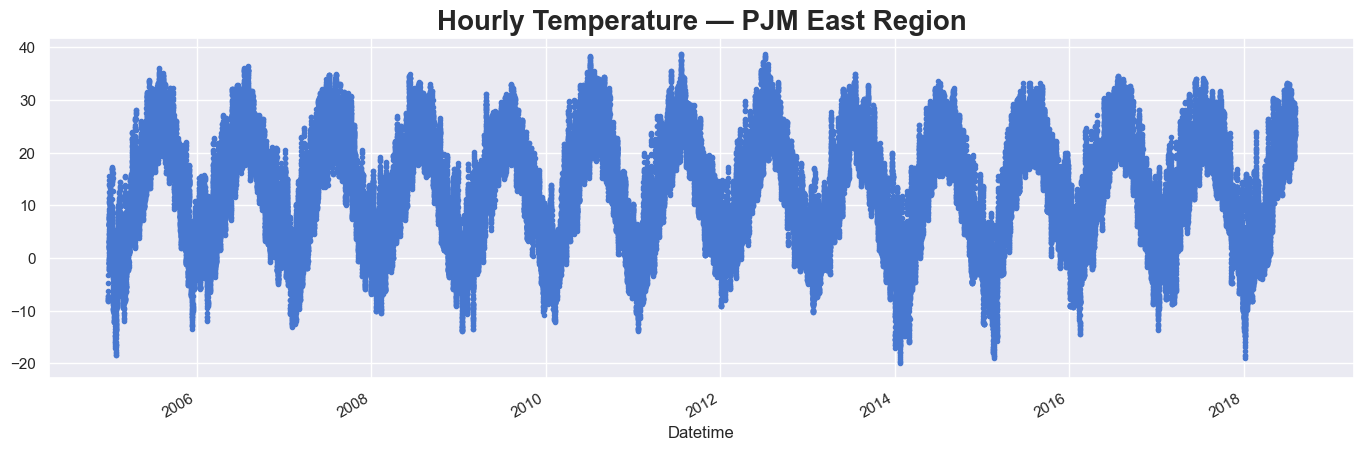

In [35]:
df['temperature'].plot(
  style=".",
  title='Hourly Temperature — PJM East Region'
)
plt.show()

<Axes: xlabel='temperature', ylabel='Count'>

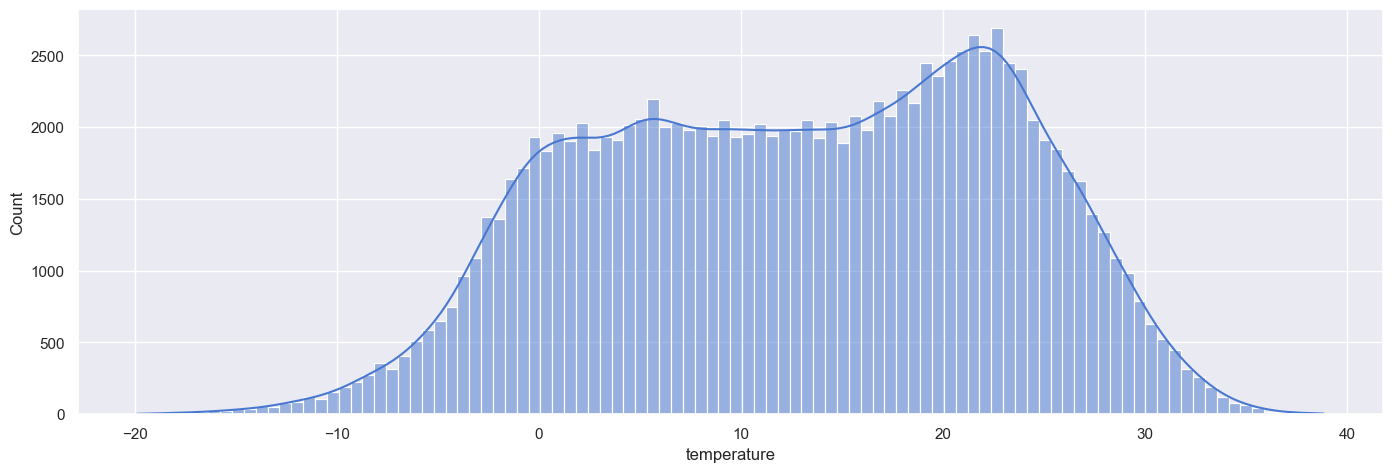

In [31]:
sns.histplot(data=df, x='temperature', bins=100, kde=True)

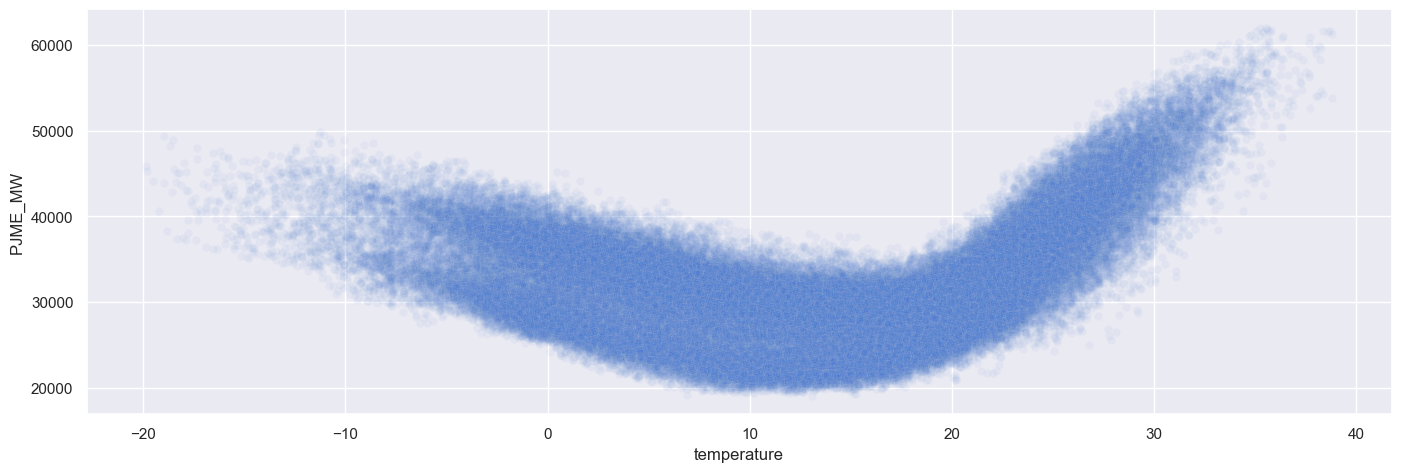

In [38]:
sns.scatterplot(data=df, x='temperature', y=TARGET, alpha=0.05)
plt.show()

<Axes: xlabel='month', ylabel='PJME_MW'>

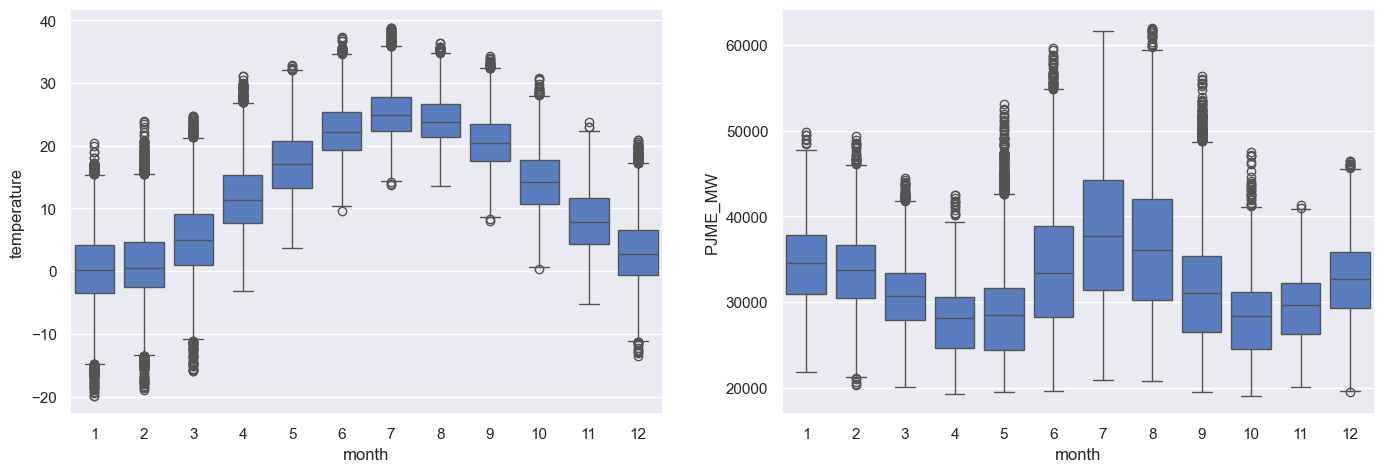

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x='month', y='temperature', ax=axes[0])
sns.boxplot(data=df, x='month', y='PJME_MW',     ax=axes[1])